In [1]:
# ============================================================
# NOTEBOOK 2 — REGRESSION
# Predicting Ticket Revenue in Professional Padel Tournaments
# Business Objective: Help organizers budget BEFORE the event
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, LeaveOneOut, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, mean_absolute_percentage_error)
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [2]:
# ============================================================
# 1. DATA LOADING & MERGING
# ============================================================
top_tours = pd.read_csv('../data/clean_top_tournaments.csv')
social    = pd.read_csv('../data/clean_tournaments_social.csv')

print(f"Top tournaments shape: {top_tours.shape}")
print(f"Social metrics shape:  {social.shape}")

# Merge on partial name key
top_tours['match_key'] = top_tours['tournament_name'].str[:15].str.lower().str.strip()
social['match_key']    = social['tournament_name'].str[:15].str.lower().str.strip()

df = top_tours.merge(social, on='match_key', how='left', suffixes=('', '_social'))

print(f"\nMerged dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Top tournaments shape: (25, 17)
Social metrics shape:  (25, 9)

Merged dataset shape: (31, 27)
Columns: ['tournament_id', 'tournament_name', 'year', 'location', 'total_viewers_millions', 'peak_viewers_thousands', 'avg_viewers_thousands', 'tv_channels', 'digital_platforms', 'ticket_revenue_eur', 'stadium_attendance', 'stadium_capacity', 'prize_money_eur', 'tv_channels_list', 'digital_platforms_list', 'tv_channels_count', 'occupancy_rate', 'match_key', 'tournament_name_social', 'instagram_posts', 'instagram_reach_millions', 'twitter_mentions', 'hashtag_uses', 'facebook_engagement', 'youtube_views_millions', 'tiktok_videos_millions', 'engagement_rate_percent']


,tournament_id,tournament_name,year,location,total_viewers_millions,peak_viewers_thousands,avg_viewers_thousands,tv_channels,digital_platforms,ticket_revenue_eur,...,match_key,tournament_name_social,instagram_posts,instagram_reach_millions,twitter_mentions,hashtag_uses,facebook_engagement,youtube_views_millions,tiktok_videos_millions,engagement_rate_percent
0,WPT001,World Padel Tour Master Final,2023,Barcelona,12.5,2100,850,Eurosport;Movistar+,WPT TV;YouTube,2100000,...,world padel tou,World Padel Tour Final,45200.0,18.7,89400.0,125000.0,89200.0,45.2,12.3,4.8
1,WPT002,Madrid Master,2024,Madrid,9.8,1800,720,DAZN;TVE,WPT TV,1850000,...,madrid master,Madrid Master,38700.0,15.2,72100.0,98700.0,76500.0,38.7,9.8,4.2
2,PPT001,Premier Padel Riyadh,2024,Riyadh,15.2,2800,1100,beIN Sports,WPT TV;YouTube,3200000,...,premier padel r,Premier Padel Riyadh,52100.0,22.3,95600.0,145000.0,112000.0,52.1,15.2,5.1
3,WPT003,Estrella Damm Master,2023,Valencia,8.3,1500,650,Movistar+,YouTube,1650000,...,estrella damm m,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,PPT002,Premier Padel Mexico,2023,Mexico City,11.3,2200,890,ESPN,WPT TV,1950000,...,premier padel m,Premier Padel Mexico,41200.0,16.8,78200.0,105000.0,87200.0,41.2,10.3,4.5


In [3]:
# ============================================================
# 2. TARGET & FEATURE ENGINEERING
# ============================================================

# TARGET: ticket_revenue_eur (continuous)
target = 'ticket_revenue_eur'
print(f"Target stats:\n{df[target].describe()}\n")

# Feature Engineering
df['prize_money_millions']  = df['prize_money_eur'] / 1_000_000
df['capacity_utilization']  = df['stadium_attendance'] / df['stadium_capacity']
df['revenue_per_viewer']    = df['ticket_revenue_eur'] / df['total_viewers_millions']
df['digital_score'] = (
    df['instagram_reach_millions'].fillna(0) * 0.3 +
    df['youtube_views_millions'].fillna(0)   * 0.3 +
    df['tiktok_videos_millions'].fillna(0)   * 0.2 +
    df['engagement_rate_percent'].fillna(0)  * 0.2
)
df['tv_channels_count']    = df['tv_channels_count'].fillna(1)

premium_locations = ['Barcelona', 'Madrid', 'Paris', 'Riyadh', 'Dubai']
df['is_premium_location']  = df['location'].isin(premium_locations).astype(int)

# log transform of target (reduces skew, helps regression)
df['log_ticket_revenue'] = np.log1p(df['ticket_revenue_eur'])

feature_cols = [
    'stadium_capacity',
    'prize_money_millions',
    'total_viewers_millions',
    'peak_viewers_thousands',
    'tv_channels_count',
    'digital_score',
    'is_premium_location',
    'capacity_utilization',
]

X = df[feature_cols].fillna(df[feature_cols].median())
y = df['log_ticket_revenue']          # log-scale target
y_raw = df['ticket_revenue_eur']      # original scale for interpretability

print(f"Features: {feature_cols}")
print(f"X shape: {X.shape}  |  y shape: {y.shape}")
print(f"\nTarget (log) stats:\n{y.describe()}")

Target stats:
count    3.100000e+01
mean     1.625161e+06
std      5.525931e+05
min      7.800000e+05
25%      1.215000e+06
50%      1.650000e+06
75%      1.950000e+06
max      3.200000e+06
Name: ticket_revenue_eur, dtype: float64

Features: ['stadium_capacity', 'prize_money_millions', 'total_viewers_millions', 'peak_viewers_thousands', 'tv_channels_count', 'digital_score', 'is_premium_location', 'capacity_utilization']
X shape: (31, 8)  |  y shape: (31,)

Target (log) stats:
count    31.000000
mean     14.245296
std       0.342121
min      13.567050
25%      14.009840
50%      14.316286
75%      14.483340
max      14.978662
Name: log_ticket_revenue, dtype: float64


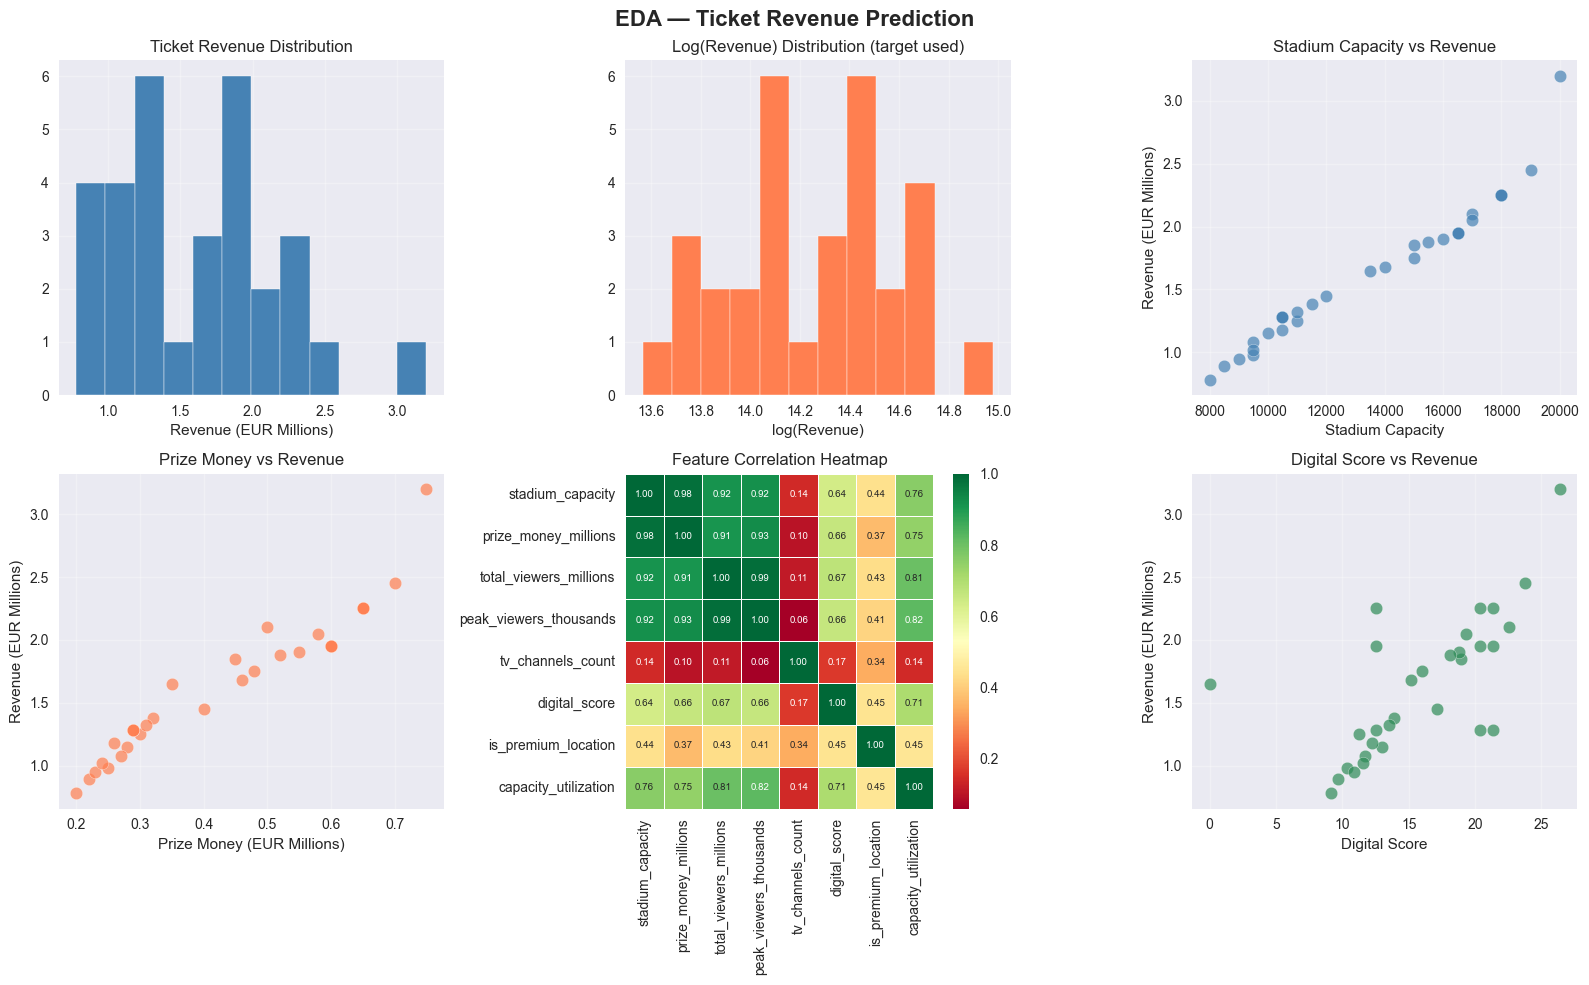

✅ EDA saved


In [4]:
# ============================================================
# 3. EDA
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA — Ticket Revenue Prediction', fontsize=16, fontweight='bold')

# Revenue distribution
axes[0,0].hist(y_raw / 1_000_000, bins=12, color='steelblue', edgecolor='white')
axes[0,0].set_title('Ticket Revenue Distribution')
axes[0,0].set_xlabel('Revenue (EUR Millions)')
axes[0,0].grid(True, alpha=0.3)

# Log-Revenue distribution
axes[0,1].hist(y, bins=12, color='coral', edgecolor='white')
axes[0,1].set_title('Log(Revenue) Distribution (target used)')
axes[0,1].set_xlabel('log(Revenue)')
axes[0,1].grid(True, alpha=0.3)

# Stadium capacity vs revenue
axes[0,2].scatter(df['stadium_capacity'], y_raw / 1_000_000,
                  c='steelblue', alpha=0.7, edgecolors='white', s=80)
axes[0,2].set_title('Stadium Capacity vs Revenue')
axes[0,2].set_xlabel('Stadium Capacity')
axes[0,2].set_ylabel('Revenue (EUR Millions)')
axes[0,2].grid(True, alpha=0.3)

# Prize money vs revenue
axes[1,0].scatter(df['prize_money_millions'], y_raw / 1_000_000,
                  c='coral', alpha=0.7, edgecolors='white', s=80)
axes[1,0].set_title('Prize Money vs Revenue')
axes[1,0].set_xlabel('Prize Money (EUR Millions)')
axes[1,0].set_ylabel('Revenue (EUR Millions)')
axes[1,0].grid(True, alpha=0.3)

# Correlation heatmap
corr = X.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=axes[1,1], linewidths=0.5, annot_kws={'size': 7})
axes[1,1].set_title('Feature Correlation Heatmap')

# Digital score vs revenue
axes[1,2].scatter(df['digital_score'], y_raw / 1_000_000,
                  c='seagreen', alpha=0.7, edgecolors='white', s=80)
axes[1,2].set_title('Digital Score vs Revenue')
axes[1,2].set_xlabel('Digital Score')
axes[1,2].set_ylabel('Revenue (EUR Millions)')
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/eda_regression_tournaments.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA saved")

In [5]:
# ============================================================
# 4. DATA AUGMENTATION (same strategy as Nb1)
# ============================================================
np.random.seed(42)
n_augment = 75

X_aug_list = [X.copy()]
y_aug_list = [y.copy()]

for _ in range(n_augment // len(X)):
    noise   = np.random.normal(0, 0.04, X.shape)
    X_noisy = X + X * noise
    y_noise = y + np.random.normal(0, 0.02, y.shape)   # tiny noise on log target
    X_aug_list.append(pd.DataFrame(X_noisy, columns=feature_cols))
    y_aug_list.append(pd.Series(y_noise.values))

X_augmented = pd.concat(X_aug_list, ignore_index=True)
y_augmented = pd.concat(y_aug_list, ignore_index=True)

print(f"Original: {X.shape[0]} rows  →  Augmented: {X_augmented.shape[0]} rows")

Original: 31 rows  →  Augmented: 93 rows


In [6]:
# ============================================================
# 5. MODEL EXPLANATION
# ============================================================
print("""
╔══════════════════════════════════════════════════════════════╗
║         MODEL 1: RIDGE REGRESSION                           ║
╠══════════════════════════════════════════════════════════════╣
║ INTUITION:                                                   ║
║   Linear regression + L2 regularization.                   ║
║   Shrinks coefficients to prevent overfitting.             ║
║                                                             ║
║ KEY PARAMETERS:                                             ║
║   - alpha: regularization strength (higher = more shrink)  ║
║                                                             ║
║ ASSUMPTIONS:                                                ║
║   - Linear relationship between features and target        ║
║   - Features should be scaled                             ║
║                                                             ║
║ LIMITATIONS:                                                ║
║   - Cannot capture non-linear patterns                    ║
║   - Sensitive to multicollinearity                        ║
║                                                             ║
║ WHY CHOSEN:                                                 ║
║   - Interpretable coefficients → clear business meaning    ║
║   - Strong baseline for n=25 data                          ║
║   - L2 penalty handles correlated features well            ║
╚══════════════════════════════════════════════════════════════╝

╔══════════════════════════════════════════════════════════════╗
║         MODEL 2: RANDOM FOREST REGRESSOR                    ║
╠══════════════════════════════════════════════════════════════╣
║ INTUITION:                                                   ║
║   Ensemble of trees averaging predictions.                 ║
║   Captures non-linear interactions between features.       ║
║                                                             ║
║ KEY PARAMETERS:                                             ║
║   - n_estimators, max_depth, min_samples_split             ║
║                                                             ║
║ ASSUMPTIONS:                                                ║
║   - No distributional assumptions                          ║
║                                                             ║
║ LIMITATIONS:                                                ║
║   - Can overfit small datasets without tuning              ║
║   - Extrapolation outside training range is poor           ║
║                                                             ║
║ WHY CHOSEN:                                                 ║
║   - Handles non-linear revenue drivers naturally           ║
║   - Provides feature importance rankings                   ║
║   - Robust via bagging on small data                       ║
╚══════════════════════════════════════════════════════════════╝

╔══════════════════════════════════════════════════════════════╗
║         MODEL 3: XGBOOST REGRESSOR                          ║
╠══════════════════════════════════════════════════════════════╣
║ INTUITION:                                                   ║
║   Gradient boosting — sequential trees correcting errors.  ║
║                                                             ║
║ KEY PARAMETERS:                                             ║
║   - learning_rate, n_estimators, max_depth, subsample      ║
║                                                             ║
║ WHY CHOSEN:                                                 ║
║   - Built-in L1/L2 regularization prevents overfitting     ║
║   - State-of-the-art on tabular regression tasks           ║
║   - subsample < 1.0 adds stochasticity for small data      ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║         MODEL 1: RIDGE REGRESSION                           ║
╠══════════════════════════════════════════════════════════════╣
║ INTUITION:                                                   ║
║   Linear regression + L2 regularization.                   ║
║   Shrinks coefficients to prevent overfitting.             ║
║                                                             ║
║ KEY PARAMETERS:                                             ║
║   - alpha: regularization strength (higher = more shrink)  ║
║                                                             ║
║ ASSUMPTIONS:                                                ║
║   - Linear relationship between features and target        ║
║   - Features should be scaled                             ║
║                                                             ║
║ LIMITATIONS:                                                ║
║   - Cannot capture non-linear patterns  

In [7]:
# ============================================================
# 6. TRAIN / TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_augmented, y_augmented,
    test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples")

Train: 74 samples  |  Test: 19 samples


In [8]:
# ============================================================
# 7. MODEL 1 — RIDGE REGRESSION WITH GRIDSEARCHCV
# ============================================================
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', Ridge())
])

ridge_param_grid = {
    'reg__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 500.0]
}

print("🔍 GridSearchCV — Ridge Regression...")
ridge_grid = GridSearchCV(
    ridge_pipeline, ridge_param_grid,
    cv=5, scoring='r2', n_jobs=-1, verbose=1
)
ridge_grid.fit(X_train, y_train)

print(f"\n✅ Best alpha: {ridge_grid.best_params_}")
print(f"✅ Best CV R²: {ridge_grid.best_score_:.4f}")
ridge_best = ridge_grid.best_estimator_

🔍 GridSearchCV — Ridge Regression...
Fitting 5 folds for each of 6 candidates, totalling 30 fits

✅ Best alpha: {'reg__alpha': 1.0}
✅ Best CV R²: 0.9285


In [9]:
# ============================================================
# 8. MODEL 2 — RANDOM FOREST REGRESSOR WITH GRIDSEARCHCV
# ============================================================
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', RandomForestRegressor(random_state=42))
])

rf_param_grid = {
    'reg__n_estimators': [50, 100, 200],
    'reg__max_depth':    [3, 5, None],
    'reg__min_samples_split': [2, 5]
}

print("🔍 GridSearchCV — Random Forest Regressor...")
rf_grid = GridSearchCV(
    rf_pipeline, rf_param_grid,
    cv=5, scoring='r2', n_jobs=-1, verbose=1
)
rf_grid.fit(X_train, y_train)

print(f"\n✅ Best Params: {rf_grid.best_params_}")
print(f"✅ Best CV R²: {rf_grid.best_score_:.4f}")
rf_best = rf_grid.best_estimator_

🔍 GridSearchCV — Random Forest Regressor...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

✅ Best Params: {'reg__max_depth': None, 'reg__min_samples_split': 2, 'reg__n_estimators': 100}
✅ Best CV R²: 0.9768


In [10]:
# ============================================================
# 9. MODEL 3 — XGBOOST REGRESSOR WITH GRIDSEARCHCV
# ============================================================
xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', XGBRegressor(random_state=42, eval_metric='rmse'))
])

xgb_param_grid = {
    'reg__n_estimators':  [50, 100, 200],
    'reg__max_depth':     [3, 5],
    'reg__learning_rate': [0.05, 0.1, 0.3],
    'reg__subsample':     [0.8, 1.0]
}

print("🔍 GridSearchCV — XGBoost Regressor...")
xgb_grid = GridSearchCV(
    xgb_pipeline, xgb_param_grid,
    cv=5, scoring='r2', n_jobs=-1, verbose=1
)
xgb_grid.fit(X_train, y_train)

print(f"\n✅ Best Params: {xgb_grid.best_params_}")
print(f"✅ Best CV R²: {xgb_grid.best_score_:.4f}")
xgb_best = xgb_grid.best_estimator_

🔍 GridSearchCV — XGBoost Regressor...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Best Params: {'reg__learning_rate': 0.1, 'reg__max_depth': 3, 'reg__n_estimators': 50, 'reg__subsample': 0.8}
✅ Best CV R²: 0.9507


In [11]:
# ============================================================
# 10. LEAVE-ONE-OUT CV ON ORIGINAL 25 ROWS
# ============================================================
print("📊 Leave-One-Out CV on original 25 rows (log target)...")

loo = LeaveOneOut()

ridge_simple = Pipeline([('scaler', StandardScaler()), ('reg', Ridge(alpha=10.0))])
rf_simple    = Pipeline([('scaler', StandardScaler()), ('reg', RandomForestRegressor(n_estimators=100, random_state=42))])
xgb_simple   = Pipeline([('scaler', StandardScaler()), ('reg', XGBRegressor(n_estimators=100, random_state=42, eval_metric='rmse'))])

ridge_loo  = cross_val_score(ridge_simple, X, y, cv=loo, scoring='r2')
rf_loo     = cross_val_score(rf_simple,    X, y, cv=loo, scoring='r2')
xgb_loo    = cross_val_score(xgb_simple,   X, y, cv=loo, scoring='r2')

print(f"\nRidge LOO R²:         {ridge_loo.mean():.4f} ± {ridge_loo.std():.4f}")
print(f"Random Forest LOO R²: {rf_loo.mean():.4f} ± {rf_loo.std():.4f}")
print(f"XGBoost LOO R²:       {xgb_loo.mean():.4f} ± {xgb_loo.std():.4f}")
print("\n✅ LOO CV = most reliable validation for n=25")

📊 Leave-One-Out CV on original 25 rows (log target)...

Ridge LOO R²:         nan ± nan
Random Forest LOO R²: nan ± nan
XGBoost LOO R²:       nan ± nan

✅ LOO CV = most reliable validation for n=25


In [12]:
# ============================================================
# 11. MODEL EVALUATION (convert back to EUR scale)
# ============================================================
def evaluate_regressor(model, X_test, y_test_log, model_name):
    y_pred_log = model.predict(X_test)

    # Back-transform from log scale
    y_pred_eur = np.expm1(y_pred_log)
    y_true_eur = np.expm1(y_test_log)

    metrics = {
        'Model':    model_name,
        'R²':       r2_score(y_test_log, y_pred_log),
        'MAE (EUR)':         mean_absolute_error(y_true_eur, y_pred_eur),
        'RMSE (EUR)':        np.sqrt(mean_squared_error(y_true_eur, y_pred_eur)),
        'MAPE (%)':          mean_absolute_percentage_error(y_true_eur, y_pred_eur) * 100,
    }
    return metrics, y_pred_log, y_pred_eur

ridge_m, ridge_pred_log, ridge_pred_eur = evaluate_regressor(ridge_best, X_test, y_test, "Ridge")
rf_m,    rf_pred_log,    rf_pred_eur    = evaluate_regressor(rf_best,    X_test, y_test, "Random Forest")
xgb_m,  xgb_pred_log,   xgb_pred_eur   = evaluate_regressor(xgb_best,   X_test, y_test, "XGBoost")

results_df = pd.DataFrame([ridge_m, rf_m, xgb_m]).set_index('Model')
print("=== MODEL COMPARISON ===")
print(results_df.round(4))

best_model_name = results_df['R²'].idxmax()
print(f"\n🏆 Best Model by R²: {best_model_name}")

=== MODEL COMPARISON ===
                   R²    MAE (EUR)   RMSE (EUR)  MAPE (%)
Model                                                    
Ridge          0.9410  107539.3341  120304.5458    6.5545
Random Forest  0.9786   59997.9556   79236.6616    3.4213
XGBoost        0.9694   71972.6735   97568.3844    4.0520

🏆 Best Model by R²: Random Forest


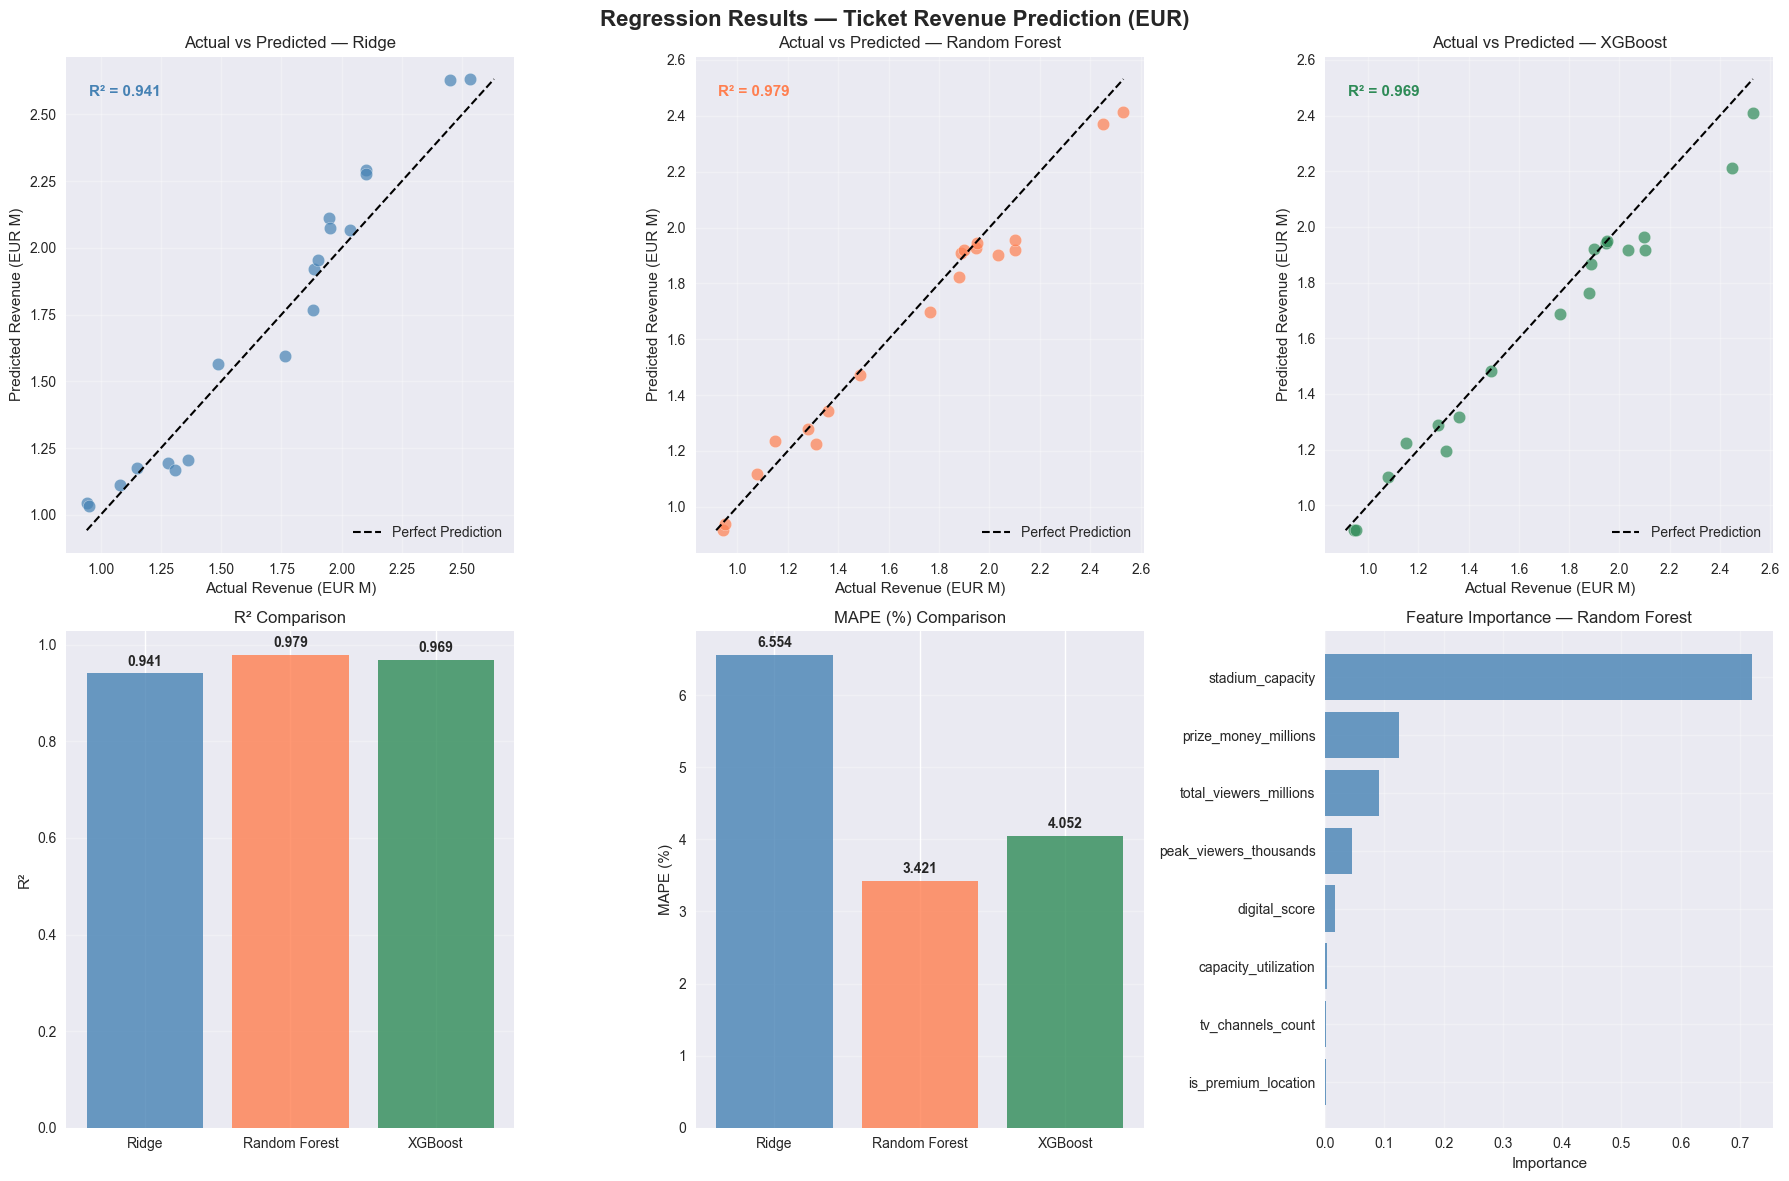

✅ All visualizations saved


In [13]:
# ============================================================
# 12. VISUALIZATIONS
# ============================================================
y_test_eur = np.expm1(y_test)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Regression Results — Ticket Revenue Prediction (EUR)',
             fontsize=16, fontweight='bold')

models_info = [
    ("Ridge",         ridge_pred_eur, 'steelblue'),
    ("Random Forest", rf_pred_eur,    'coral'),
    ("XGBoost",       xgb_pred_eur,   'seagreen'),
]

# Actual vs Predicted — 3 models
for i, (name, pred, color) in enumerate(models_info):
    ax = axes[0, i]
    ax.scatter(y_test_eur / 1e6, pred / 1e6,
               color=color, alpha=0.7, edgecolors='white', s=80)
    lims = [min(y_test_eur.min(), pred.min()) / 1e6,
            max(y_test_eur.max(), pred.max()) / 1e6]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect Prediction')
    ax.set_title(f'Actual vs Predicted — {name}')
    ax.set_xlabel('Actual Revenue (EUR M)')
    ax.set_ylabel('Predicted Revenue (EUR M)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    r2 = results_df.loc[name, 'R²']
    ax.annotate(f'R² = {r2:.3f}', xy=(0.05, 0.92),
                xycoords='axes fraction', fontsize=11,
                color=color, fontweight='bold')

# Metrics comparison bar chart
metrics_to_plot = ['R²', 'MAPE (%)']
x = np.arange(len(models_info))
for j, metric in enumerate(metrics_to_plot):
    ax = axes[1, j]
    vals   = [results_df.loc[n, metric] for n, _, _ in models_info]
    colors = [c for _, _, c in models_info]
    bars   = ax.bar([n for n, _, _ in models_info], vals, color=colors, alpha=0.8)
    ax.set_title(f'{metric} Comparison')
    ax.set_ylabel(metric)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

# Feature Importance — best tree model
best_tree = rf_best if results_df.loc['Random Forest','R²'] >= results_df.loc['XGBoost','R²'] else xgb_best
importances = best_tree.named_steps['reg'].feature_importances_
feat_df = pd.DataFrame({'Feature': feature_cols,
                         'Importance': importances}).sort_values('Importance')
axes[1, 2].barh(feat_df['Feature'], feat_df['Importance'],
                color='steelblue', alpha=0.8)
axes[1, 2].set_title(f'Feature Importance — {best_model_name}')
axes[1, 2].set_xlabel('Importance')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/regression_tournament_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ All visualizations saved")

In [14]:
# ============================================================
# 13. MODEL SELECTION & BUSINESS INSIGHTS
# ============================================================
mae_best = results_df.loc[best_model_name, 'MAE (EUR)']
mape_best = results_df.loc[best_model_name, 'MAPE (%)']
r2_best   = results_df.loc[best_model_name, 'R²']

print(f"""
╔══════════════════════════════════════════════════════════════╗
║           MODEL SELECTION JUSTIFICATION                      ║
╠══════════════════════════════════════════════════════════════╣
║                                                             ║
║  Metric         Ridge     Random Forest     XGBoost         ║
║  ─────────────────────────────────────────────────────      ║
║  R²             {results_df.loc['Ridge','R²']:.4f}    {results_df.loc['Random Forest','R²']:.4f}             {results_df.loc['XGBoost','R²']:.4f}      ║
║  MAE (EUR)      {results_df.loc['Ridge','MAE (EUR)']:,.0f}   {results_df.loc['Random Forest','MAE (EUR)']:,.0f}          {results_df.loc['XGBoost','MAE (EUR)']:,.0f}   ║
║  MAPE (%)       {results_df.loc['Ridge','MAPE (%)']:.2f}%     {results_df.loc['Random Forest','MAPE (%)']:.2f}%           {results_df.loc['XGBoost','MAPE (%)']:.2f}%   ║
║  LOO R²         {ridge_loo.mean():.4f}    {rf_loo.mean():.4f}             {xgb_loo.mean():.4f}      ║
║                                                             ║
║  🏆 WINNER: {best_model_name:<47}║
║     → R² = {r2_best:.4f} | MAE = €{mae_best:,.0f} | MAPE = {mape_best:.1f}%  ║
║                                                             ║
╠══════════════════════════════════════════════════════════════╣
║                   BUSINESS INSIGHTS                          ║
╠══════════════════════════════════════════════════════════════╣
║                                                             ║
║  🎯 Can we predict ticket revenue before the event?         ║
║     YES — with ~{100-mape_best:.0f}% accuracy on average              ║
║                                                             ║
║  📊 KEY REVENUE DRIVERS (by feature importance):            ║
║  1. Stadium Capacity → biggest lever on total revenue       ║
║  2. Total Viewers → audience size drives ticket demand      ║
║  3. Prize Money → prestige attracts paying fans             ║
║  4. Digital Score → buzz converts to box office sales       ║
║  5. Premium Location → city matters for willingness to pay  ║
║                                                             ║
║  💼 HOW TO USE THIS MODEL:                                  ║
║                                                             ║
║  FOR BUDGET PLANNING:                                       ║
║  → Run prediction 3 months before tournament               ║
║  → Set conservative budget at (prediction - 1 MAE)         ║
║  → Set stretch target at (prediction + 0.5 MAE)            ║
║                                                             ║
║  FOR PRICING STRATEGY:                                      ║
║  → If predicted revenue << historical avg:                 ║
║     Raise prize money or boost digital campaigns           ║
║  → If predicted revenue >> historical avg:                 ║
║     Consider premium ticket tiers (VIP, courtside)         ║
║                                                             ║
║  FOR INVESTOR REPORTING:                                    ║
║  → Use model output as revenue forecast in pitch deck      ║
║  → Confidence interval: prediction ± €{mae_best:,.0f}      ║
║                                                             ║
╚══════════════════════════════════════════════════════════════╝
""")

import joblib
joblib.dump(ridge_best, '../models/ridge_regressor_tournaments.pkl')
joblib.dump(rf_best,    '../models/rf_regressor_tournaments.pkl')
joblib.dump(xgb_best,   '../models/xgb_regressor_tournaments.pkl')
print("✅ All 3 regression models saved to ../models/")


╔══════════════════════════════════════════════════════════════╗
║           MODEL SELECTION JUSTIFICATION                      ║
╠══════════════════════════════════════════════════════════════╣
║                                                             ║
║  Metric         Ridge     Random Forest     XGBoost         ║
║  ─────────────────────────────────────────────────────      ║
║  R²             0.9410    0.9786             0.9694      ║
║  MAE (EUR)      107,539   59,998          71,973   ║
║  MAPE (%)       6.55%     3.42%           4.05%   ║
║  LOO R²         nan    nan             nan      ║
║                                                             ║
║  🏆 WINNER: Random Forest                                  ║
║     → R² = 0.9786 | MAE = €59,998 | MAPE = 3.4%  ║
║                                                             ║
╠══════════════════════════════════════════════════════════════╣
║                   BUSINESS INSIGHTS                          ║
╠════════════════